---
title: "Лабораторна робота №7. Аналіз тональності тексту"
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
author: "&copy; [Valeriy Sydorenko](https://github.com/)"
date: today
lang: uk

format:
  html:
    code-fold: show
    code-tools: true
    toc: true
    toc-depth: 3
    number-sections: false
jupyter: python3
---


::: callout-note
## Примітка

Для виконання роботи потрібно опрацювати *лекцію 7* -- насамперед питання *поняття тональності*, *полярності і суб'єктивності*, *лексиконних методів*, *побудови моделей sentiment analysis* та *метрик оцінювання якості*.

Зошит побудовано так, щоб його можна було виконувати послідовно навіть на *невеликому навчальному корпусі*. Основна ідея роботи полягає у тому, щоб пройти повний шлях від *розміченого набору повідомлень* до *побудови і порівняння моделей аналізу тональності*.
:::

## Мета роботи

Опанувати базові підходи до *аналізу тональності тексту*: формування розміченого корпусу, базове очищення повідомлень, побудову *лексиконного baseline*, векторизацію текстів за допомогою *TF-IDF*, навчання моделей *Naive Bayes*, *Logistic Regression* та *Linear SVM*, а також оцінювання якості класифікації за стандартними метриками.

## Що ви будете вміти після виконання роботи?

Після виконання лабораторної роботи ви будете вміти:

- формувати невеликий *розмічений корпус* для задач sentiment analysis;
- виконувати базове очищення коротких повідомлень;
- застосовувати *простий словниковий підхід* до оцінювання тональності;
- будувати *TF-IDF*-представлення текстів;
- навчати моделі *Naive Bayes*, *Logistic Regression* та *Linear SVM* для класифікації тональності;
- порівнювати моделі за метриками *accuracy*, *precision*, *recall* та *F1-score*;
- будувати *матрицю помилок* і аналізувати типові хибні прогнози;
- перевіряти модель на *нових власних фразах*.

## Теоретичні відомості

У лекції 7 було показано, що *аналіз тональності тексту* є окремим прикладним випадком задачі класифікації текстів. На відміну від тематичної класифікації, де нас цікавить зміст документа, у sentiment analysis нас цікавить *оцінна спрямованість* висловлювання.

У найпростішому варіанті будемо розглядати три класи:

- `positive` -- позитивна тональність;
- `negative` -- негативна тональність;
- `neutral` -- нейтральне повідомлення без виразної оцінки.

У практиці аналізу тональності часто використовують два базові підходи.

### 1. Лексиконний підхід

Маємо словник оцінних слів із вагами. Для кожного тексту підсумовуємо знайдені оцінки і на основі знака або величини підсумку робимо висновок про тональність.

### 2. Моделі машинного навчання

Маємо розмічений корпус повідомлень. Після очищення текст перетворюється на *вектор ознак*, наприклад через *TF-IDF*. Далі модель навчається зіставляти ознаки тексту з мітками класів. У цій роботі буде використано три класичні моделі:

- *Multinomial Naive Bayes*;
- *Logistic Regression*;
- *Linear SVM*.

Якість моделі оцінюємо на *тестовій вибірці*, яка не використовувалась під час навчання.

## Постановка завдання

Потрібно сформувати *навчальний корпус повідомлень* і виконати для нього такі кроки:

1. підготувати *розмічений* корпус текстів;
2. виконати базове очищення повідомлень;
3. побудувати *простий лексиконний baseline*;
4. побудувати *TF-IDF*-матрицю;
5. розбити дані на *навчальну* та *тестову* вибірки;
6. навчити моделі *Naive Bayes*, *Logistic Regression* та *Linear SVM*;
7. порівняти якість моделей;
8. побудувати *матрицю помилок* для найкращої моделі;
9. перевірити роботу моделі на *нових прикладах*;
10. зробити змістовні висновки.

In [1]:
# Базові імпорти
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_colwidth", 120)


## 1. Формування базового корпусу

Нижче наведено невеликий навчальний корпус українською мовою. Повідомлення спеціально підібрано так, щоб у корпусі були *три класи тональності*:

- `positive` -- позитивна оцінка;
- `negative` -- негативна оцінка;
- `neutral` -- нейтральний опис без виразної оцінки.

Корпус невеликий, але для навчальних цілей цього достатньо.

In [2]:
base_corpus = [
    ("b001", "positive", "сервіс працює швидко і дуже зручно"),
    ("b002", "positive", "мені сподобався новий дизайн застосунку"),
    ("b003", "positive", "платформа стабільна та корисна для роботи"),
    ("b004", "positive", "це чудовий інструмент для аналізу повідомлень"),
    ("b005", "positive", "інтерфейс зрозумілий і приємний у використанні"),
    ("b006", "positive", "оновлення значно покращило якість роботи системи"),
    ("b007", "positive", "підтримка відповіла швидко і допомогла вирішити проблему"),
    ("b008", "positive", "результат виявився точним і дуже корисним"),
    ("b009", "positive", "додаток працює надійно навіть при великому навантаженні"),
    ("b010", "positive", "курс побудовано логічно і матеріал пояснено добре"),
    ("b011", "positive", "мені дуже сподобалась функція автоматичного аналізу"),
    ("b012", "positive", "цей підхід дає якісні та зрозумілі результати"),
    ("b013", "positive", "система коректно визначає позитивні повідомлення"),
    ("b014", "positive", "робота виконана акуратно і виглядає переконливо"),
    ("b015", "positive", "програма зручна швидка і достатньо точна"),
    ("b016", "negative", "сервіс працює повільно і часто зависає"),
    ("b017", "negative", "новий дизайн виявився незручним і заплутаним"),
    ("b018", "negative", "платформа нестабільна та дає багато помилок"),
    ("b019", "negative", "це поганий інструмент для аналізу повідомлень"),
    ("b020", "negative", "інтерфейс незрозумілий і дратує під час роботи"),
    ("b021", "negative", "оновлення лише погіршило роботу системи"),
    ("b022", "negative", "підтримка відповіла із запізненням і не допомогла"),
    ("b023", "negative", "результат виявився неточним і мало корисним"),
    ("b024", "negative", "додаток часто аварійно завершує роботу"),
    ("b025", "negative", "курс подано хаотично і пояснення слабкі"),
    ("b026", "negative", "мені не сподобалась якість автоматичного аналізу"),
    ("b027", "negative", "цей підхід дає суперечливі та ненадійні результати"),
    ("b028", "negative", "система помилково визначає тональність повідомлень"),
    ("b029", "negative", "робота виконана недбало і виглядає сирою"),
    ("b030", "negative", "програма незручна повільна і неточна"),
    ("b031", "neutral", "сьогодні система обробила двадцять повідомлень"),
    ("b032", "neutral", "користувач надіслав текст у форму аналізу"),
    ("b033", "neutral", "звіт містить таблицю графік і короткий коментар"),
    ("b034", "neutral", "модель було навчено на розміченому корпусі текстів"),
    ("b035", "neutral", "у наборі даних є три класи тональності"),
    ("b036", "neutral", "після очищення тексту побудовано tf idf представлення"),
    ("b037", "neutral", "експеримент виконано у середовищі python"),
    ("b038", "neutral", "дослідник зберіг результати у файл csv"),
    ("b039", "neutral", "повідомлення містить емодзі та кілька хештегів"),
    ("b040", "neutral", "у статті розглянуто методи аналізу тональності"),
    ("b041", "neutral", "вибірка поділена на навчальну та тестову частини"),
    ("b042", "neutral", "алгоритм повернув прогноз для кожного документа"),
    ("b043", "neutral", "корпус складається з коротких повідомлень українською мовою"),
    ("b044", "neutral", "у зошиті використано pandas matplotlib та sklearn"),
    ("b045", "neutral", "після навчання моделі обчислено метрики якості"),
]

corpus_df = pd.DataFrame(base_corpus, columns=["doc_id", "label", "text"])
corpus_df.head(10)

,doc_id,label,text
0,b001,positive,сервіс працює швидко і дуже зручно
1,b002,positive,мені сподобався новий дизайн застосунку
2,b003,positive,платформа стабільна та корисна для роботи
3,b004,positive,це чудовий інструмент для аналізу повідомлень
4,b005,positive,інтерфейс зрозумілий і приємний у використанні
5,b006,positive,оновлення значно покращило якість роботи системи
6,b007,positive,підтримка відповіла швидко і допомогла вирішити проблему
7,b008,positive,результат виявився точним і дуже корисним
8,b009,positive,додаток працює надійно навіть при великому навантаженні
9,b010,positive,курс побудовано логічно і матеріал пояснено добре


## 2. Додавання індивідуальної частини корпусу

За аналогією з попередніми лабораторними роботами, ви можете:

- дописати власні повідомлення безпосередньо у список `student_docs`;
- або підключити окремий CSV-файл з індивідуальною вибіркою.

Рекомендується додати *6--9 коротких повідомлень* так, щоб серед них були приклади різної тональності.

In [3]:
# ДОДАЙТЕ СЮДИ ВЛАСНІ РОЗМІЧЕНІ ПОВІДОМЛЕННЯ
# Формат: ("s001", "positive", "текст повідомлення")

student_docs = [
    ("s001", "positive", "сервіс виявився дуже корисним і зручним"),
    ("s002", "negative", "цей інтерфейс дратує і працює нестабільно"),
    ("s003", "neutral", "у звіті наведено результати за три дні"),
]

student_df = pd.DataFrame(student_docs, columns=["doc_id", "label", "text"])
student_df

,doc_id,label,text
0,s001,positive,сервіс виявився дуже корисним і зручним
1,s002,negative,цей інтерфейс дратує і працює нестабільно
2,s003,neutral,у звіті наведено результати за три дні


### За бажанням: завантаження індивідуального корпусу з CSV

Якщо у вас уже є окремий файл з розміченими повідомленнями, його можна підключити замість ручного списку. Очікується структура з трьома стовпцями:

- `doc_id`
- `text`
- `label`

In [ ]:
# csv_path = Path("data\lab7_sentiment_ua.csv")
# if csv_path.exists():
#     student_df = pd.read_csv(csv_path)
#     print("CSV успішно завантажено:", student_df.shape)
# else:
#     print("Файл не знайдено")

## 3. Об'єднання базового та індивідуального корпусу

Після цього формуємо *єдиний корпус*, який і буде використовуватись у подальшому аналізі.

In [4]:
corpus_df = pd.concat([corpus_df, student_df], ignore_index=True)

corpus_df["doc_id"] = corpus_df["doc_id"].astype(str)
corpus_df["label"] = corpus_df["label"].astype(str).str.strip().str.lower()
corpus_df["text"] = corpus_df["text"].astype(str)

print("Розмір корпусу:", corpus_df.shape)
corpus_df.sample(min(8, len(corpus_df)), random_state=42)

Розмір корпусу: (48, 3)


,doc_id,label,text
27,b028,negative,система помилково визначає тональність повідомлень
40,b041,neutral,вибірка поділена на навчальну та тестову частини
26,b027,negative,цей підхід дає суперечливі та ненадійні результати
43,b044,neutral,у зошиті використано pandas matplotlib та sklearn
24,b025,negative,курс подано хаотично і пояснення слабкі
37,b038,neutral,дослідник зберіг результати у файл csv
12,b013,positive,система коректно визначає позитивні повідомлення
19,b020,negative,інтерфейс незрозумілий і дратує під час роботи


## 4. Базове очищення тексту

Для навчальної задачі використаємо просту функцію очищення:

- переведення до нижнього регістру;
- видалення всіх символів, окрім літер, цифр і пробілів;
- усунення зайвих пробілів.

In [5]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^а-щьюяєіїґa-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

corpus_df["clean_text"] = corpus_df["text"].apply(clean_text)
corpus_df[["doc_id", "label", "text", "clean_text"]].head(10)

,doc_id,label,text,clean_text
0,b001,positive,сервіс працює швидко і дуже зручно,сервіс працює швидко і дуже зручно
1,b002,positive,мені сподобався новий дизайн застосунку,мені сподобався новий дизайн застосунку
2,b003,positive,платформа стабільна та корисна для роботи,платформа стабільна та корисна для роботи
3,b004,positive,це чудовий інструмент для аналізу повідомлень,це чудовий інструмент для аналізу повідомлень
4,b005,positive,інтерфейс зрозумілий і приємний у використанні,інтерфейс зрозумілий і приємний у використанні
5,b006,positive,оновлення значно покращило якість роботи системи,оновлення значно покращило якість роботи системи
6,b007,positive,підтримка відповіла швидко і допомогла вирішити проблему,підтримка відповіла швидко і допомогла вирішити проблему
7,b008,positive,результат виявився точним і дуже корисним,результат виявився точним і дуже корисним
8,b009,positive,додаток працює надійно навіть при великому навантаженні,додаток працює надійно навіть при великому навантаженні
9,b010,positive,курс побудовано логічно і матеріал пояснено добре,курс побудовано логічно і матеріал пояснено добре


## 5. Перевірка розподілу класів

Перед навчанням моделей варто перевірити, наскільки збалансованим є корпус за класами тональності.

In [6]:
class_counts = corpus_df["label"].value_counts().sort_index()
class_counts

label
negative    16
neutral     16
positive    16
Name: count, dtype: int64

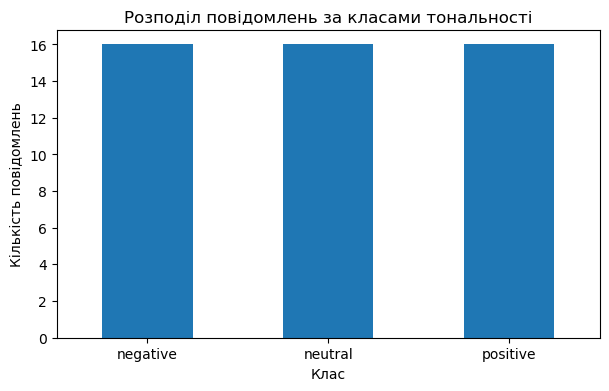

In [7]:
plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")
plt.title("Розподіл повідомлень за класами тональності")
plt.xlabel("Клас")
plt.ylabel("Кількість повідомлень")
plt.xticks(rotation=0)
plt.show()

## 6. Простий лексиконний baseline

У лекції 7 розглядався *лексиконний підхід*. Нижче реалізовано дуже спрощений варіант такого підходу. Він не претендує на високу якість, але дає важливу *базову точку відліку*.

In [8]:
sentiment_lexicon = {
    "чудовий": 2, "добрий": 1, "зручний": 1, "корисний": 1, "приємний": 1,
    "швидко": 1, "швидкий": 1, "надійний": 1, "стабільна": 1, "стабільний": 1,
    "сподобався": 1, "покращило": 1, "точним": 1, "якісні": 1, "добре": 1,
    "поганий": -1, "повільно": -1, "повільний": -1, "нестабільно": -1,
    "нестабільна": -1, "помилок": -1, "незручним": -1, "незручна": -1,
    "дратує": -1, "погіршило": -1, "неточним": -1, "хаотично": -1,
    "слабкі": -1, "недбало": -1, "неточна": -1, "зависає": -1,
}

def lexicon_score(text: str, lexicon: dict) -> int:
    tokens = text.split()
    return sum(lexicon.get(token, 0) for token in tokens)

def lexicon_predict(text: str, lexicon: dict) -> str:
    score = lexicon_score(text, lexicon)
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    return "neutral"

corpus_df["lexicon_score"] = corpus_df["clean_text"].apply(lambda x: lexicon_score(x, sentiment_lexicon))
corpus_df["lexicon_pred"] = corpus_df["clean_text"].apply(lambda x: lexicon_predict(x, sentiment_lexicon))

corpus_df[["text", "label", "lexicon_score", "lexicon_pred"]].head(12)

,text,label,lexicon_score,lexicon_pred
0,сервіс працює швидко і дуже зручно,positive,1,positive
1,мені сподобався новий дизайн застосунку,positive,1,positive
2,платформа стабільна та корисна для роботи,positive,1,positive
3,це чудовий інструмент для аналізу повідомлень,positive,2,positive
4,інтерфейс зрозумілий і приємний у використанні,positive,1,positive
5,оновлення значно покращило якість роботи системи,positive,1,positive
6,підтримка відповіла швидко і допомогла вирішити проблему,positive,1,positive
7,результат виявився точним і дуже корисним,positive,1,positive
8,додаток працює надійно навіть при великому навантаженні,positive,0,neutral
9,курс побудовано логічно і матеріал пояснено добре,positive,1,positive


## 7. Оцінювання лексиконного baseline

Оскільки словниковий підхід не потребує навчання, його можна відразу перевірити на всьому корпусі. Це не зовсім те саме, що чесна тестова оцінка для моделей машинного навчання, але для *baseline* такий крок є методично виправданим.

In [9]:
lexicon_accuracy = accuracy_score(corpus_df["label"], corpus_df["lexicon_pred"])
print("Accuracy лексиконного baseline:", round(lexicon_accuracy, 4))
print()
print(classification_report(corpus_df["label"], corpus_df["lexicon_pred"], zero_division=0))

Accuracy лексиконного baseline: 0.7708

              precision    recall  f1-score   support

    negative       1.00      0.69      0.81        16
     neutral       0.59      1.00      0.74        16
    positive       1.00      0.62      0.77        16

    accuracy                           0.77        48
   macro avg       0.86      0.77      0.78        48
weighted avg       0.86      0.77      0.78        48



## 8. Побудова TF-IDF-матриці

Далі переходимо до моделей машинного навчання. Для цього перетворимо очищені тексти на числові вектори за допомогою *TF-IDF*. Використаємо уніграми та біграми, щоб частково врахувати короткі словосполучення.

In [10]:
vectorizer = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
X = vectorizer.fit_transform(corpus_df["clean_text"])
y = corpus_df["label"]

print("Розмір TF-IDF-матриці:", X.shape)
print("Кількість ознак:", len(vectorizer.get_feature_names_out()))

Розмір TF-IDF-матриці: (48, 394)
Кількість ознак: 394


## 9. Розбиття даних на навчальну та тестову вибірки

Щоб оцінити узагальнювальну здатність моделей, поділимо корпус на дві частини:

- *навчальна вибірка* -- для навчання;
- *тестова вибірка* -- для незалежної перевірки.

In [11]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, corpus_df.index,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (33, 394)
Тестова вибірка: (15, 394)


## 10. Навчання моделі Multinomial Naive Bayes

Ця модель добре підходить для задач класифікації текстів, коли ознаки представлені частотними або *TF-IDF*-характеристиками.

In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Accuracy Naive Bayes:", round(accuracy_score(y_test, y_pred_nb), 4))
print()
print(classification_report(y_test, y_pred_nb, zero_division=0))

Accuracy Naive Bayes: 0.2667

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         5
     neutral       0.50      0.40      0.44         5
    positive       0.25      0.40      0.31         5

    accuracy                           0.27        15
   macro avg       0.25      0.27      0.25        15
weighted avg       0.25      0.27      0.25        15



## 11. Навчання моделі Logistic Regression

*Логістична регресія* є однією з найпоширеніших моделей для задач класифікації тексту. Вона добре працює з розрідженими векторними представленнями і дозволяє інтерпретувати ваги ознак.

In [13]:
lr_model = LogisticRegression(max_iter=3000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy Logistic Regression:", round(accuracy_score(y_test, y_pred_lr), 4))
print()
print(classification_report(y_test, y_pred_lr, zero_division=0))

Accuracy Logistic Regression: 0.4

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         5
     neutral       0.67      0.80      0.73         5
    positive       0.29      0.40      0.33         5

    accuracy                           0.40        15
   macro avg       0.32      0.40      0.35        15
weighted avg       0.32      0.40      0.35        15



## 12. Навчання моделі Linear SVM

*Linear SVM* часто показує дуже хороші результати у задачах текстової класифікації, особливо коли ознаковий простір має велику розмірність.

In [14]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy Linear SVM:", round(accuracy_score(y_test, y_pred_svm), 4))
print()
print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy Linear SVM: 0.4

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         5
     neutral       0.67      0.80      0.73         5
    positive       0.29      0.40      0.33         5

    accuracy                           0.40        15
   macro avg       0.32      0.40      0.35        15
weighted avg       0.32      0.40      0.35        15



## 13. Порівняння результатів моделей

Зведемо основні результати в одну таблицю. Для *лексиконного baseline* тут показано оцінку на всьому корпусі, а для моделей машинного навчання -- оцінку на тестовій вибірці.

In [15]:
results_df = pd.DataFrame([
    {"model": "Lexicon baseline", "accuracy": accuracy_score(corpus_df["label"], corpus_df["lexicon_pred"])},
    {"model": "Multinomial Naive Bayes", "accuracy": accuracy_score(y_test, y_pred_nb)},
    {"model": "Logistic Regression", "accuracy": accuracy_score(y_test, y_pred_lr)},
    {"model": "Linear SVM", "accuracy": accuracy_score(y_test, y_pred_svm)},
]).sort_values("accuracy", ascending=False)

results_df

,model,accuracy
0,Lexicon baseline,0.770833
2,Logistic Regression,0.400000
3,Linear SVM,0.400000
1,Multinomial Naive Bayes,0.266667


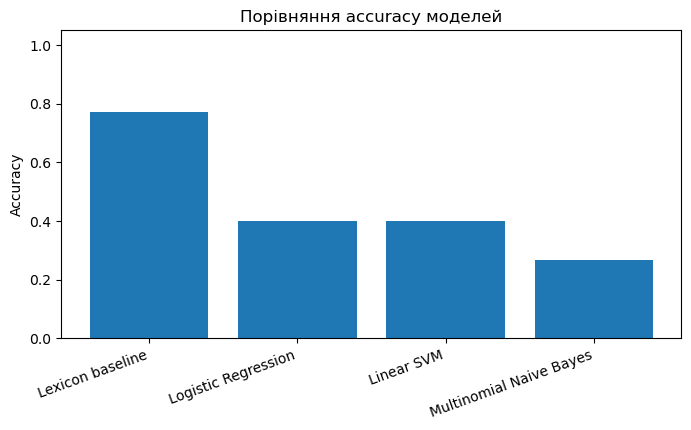

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Порівняння accuracy моделей")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.show()

## 14. Матриця помилок для найкращої моделі

У цьому блоці автоматично вибираємо найкращу модель за значенням *accuracy* на тестовій вибірці і будуємо для неї *матрицю помилок*.

Найкраща модель на тестовій вибірці: Logistic Regression
Accuracy: 0.4


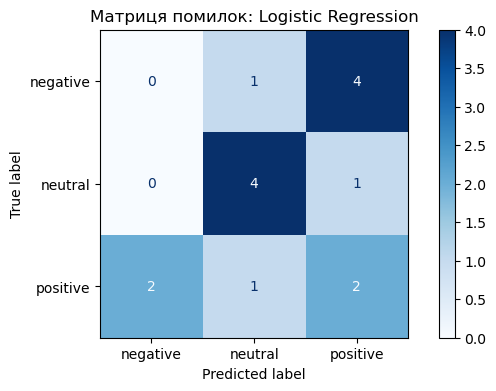

In [17]:
test_model_predictions = {
    "Multinomial Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm,
}

best_model_name = max(
    test_model_predictions.keys(),
    key=lambda name: accuracy_score(y_test, test_model_predictions[name])
)
best_predictions = test_model_predictions[best_model_name]

print("Найкраща модель на тестовій вибірці:", best_model_name)
print("Accuracy:", round(accuracy_score(y_test, best_predictions), 4))

labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, best_predictions, labels=labels_sorted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap="Blues")
plt.title(f"Матриця помилок: {best_model_name}")
plt.show()

## 15. Перегляд конкретних прогнозів

Тепер подивимось, які саме повідомлення потрапили до тестової вибірки і як їх класифікувала найкраща модель.

In [18]:
test_predictions_df = corpus_df.loc[idx_test, ["doc_id", "text", "label"]].copy()
test_predictions_df["predicted"] = best_predictions
test_predictions_df["is_correct"] = test_predictions_df["label"] == test_predictions_df["predicted"]

test_predictions_df.sort_values(["is_correct", "label"])

,doc_id,text,label,predicted,is_correct
21,b022,підтримка відповіла із запізненням і не допомогла,negative,positive,False
27,b028,система помилково визначає тональність повідомлень,negative,neutral,False
22,b023,результат виявився неточним і мало корисним,negative,positive,False
18,b019,це поганий інструмент для аналізу повідомлень,negative,positive,False
25,b026,мені не сподобалась якість автоматичного аналізу,negative,positive,False
41,b042,алгоритм повернув прогноз для кожного документа,neutral,positive,False
12,b013,система коректно визначає позитивні повідомлення,positive,neutral,False
9,b010,курс побудовано логічно і матеріал пояснено добре,positive,negative,False
11,b012,цей підхід дає якісні та зрозумілі результати,positive,negative,False
31,b032,користувач надіслав текст у форму аналізу,neutral,neutral,True


## 16. Інтерпретація ознак у Logistic Regression

Однією з переваг *Logistic Regression* є можливість подивитися, які ознаки найбільше сприяють тому чи іншому класу. Нижче для кожного класу виводяться кілька найхарактерніших термінів.

In [19]:
feature_names = np.array(vectorizer.get_feature_names_out())
class_names = lr_model.classes_
top_k = 8

for class_index, class_name in enumerate(class_names):
    coefs = lr_model.coef_[class_index]
    top_features = feature_names[np.argsort(coefs)[-top_k:]][::-1]
    print(f"Клас: {class_name}")
    print(", ".join(top_features))
    print("-" * 60)

Клас: negative
часто, роботу, дратує, цей, дає, повільна, неточна, програма незручна
------------------------------------------------------------
Клас: neutral
містить, на, виконано, виконано середовищі, експеримент, експеримент виконано, середовищі python, середовищі
------------------------------------------------------------
Клас: positive
швидко, дуже, для, роботи, зрозумілий приємний, зрозумілий, інтерфейс зрозумілий, приємний використанні
------------------------------------------------------------


## 17. Короткий експеримент з новими текстами

У цьому блоці можна перевірити роботу моделей на нових коротких фразах. Це дозволяє швидко побачити, як змінюються прогнози на прикладах, яких не було в корпусі.

In [20]:
new_texts = [
    "цей сервіс працює чудово і дуже швидко",
    "додаток жахливо зависає і дратує",
    "у звіті наведено результати експерименту за тиждень",
    "інтерфейс став зручнішим після оновлення",
    "я не задоволений якістю роботи системи",
]

new_texts_clean = [clean_text(text) for text in new_texts]
X_new = vectorizer.transform(new_texts_clean)

new_predictions_df = pd.DataFrame({
    "text": new_texts,
    "lexicon_pred": [lexicon_predict(text, sentiment_lexicon) for text in new_texts_clean],
    "nb_pred": nb_model.predict(X_new),
    "lr_pred": lr_model.predict(X_new),
    "svm_pred": svm_model.predict(X_new),
})

new_predictions_df

,text,lexicon_pred,nb_pred,lr_pred,svm_pred
0,цей сервіс працює чудово і дуже швидко,positive,positive,positive,positive
1,додаток жахливо зависає і дратує,negative,negative,negative,negative
2,у звіті наведено результати експерименту за тиждень,neutral,neutral,neutral,neutral
3,інтерфейс став зручнішим після оновлення,neutral,negative,negative,negative
4,я не задоволений якістю роботи системи,neutral,positive,positive,positive


## 18. Коротка інтерпретація результатів

На цьому етапі потрібно звернути увагу на кілька моментів:

- чи перевищують моделі машинного навчання простий *лексиконний baseline*;
- які класи модель плутає найчастіше;
- чи є складними для моделі *нейтральні* повідомлення;
- як реагують моделі на короткі нові фрази.

## Висновки

У висновках до роботи доцільно відобразити:

1. який корпус було використано;
2. як виконувалось очищення тексту;
3. який результат показав *лексиконний baseline*;
4. яка з моделей машинного навчання виявилась найкращою;
5. які типові труднощі спостерігались під час класифікації;
6. які обмеження має побудований навчальний приклад.

## Індивідуальне завдання

1. Додайте до корпусу не менше *9 власних повідомлень*.
2. Перевірте, як зміниться якість моделей після розширення корпусу.
3. Модифікуйте словник `sentiment_lexicon`, додавши власні оцінні слова.
4. Порівняйте результати для `ngram_range=(1, 1)` та `ngram_range=(1, 2)`.
5. Підготуйте 5 нових тестових фраз і поясніть отримані прогнози.

## Контрольні питання

1. У чому полягає відмінність між *тематичною класифікацією* та *аналізом тональності*?
2. Що таке *лексиконний підхід* до sentiment analysis?
3. Для чого потрібне *TF-IDF*-представлення?
4. Чому вибірку потрібно ділити на *навчальну* і *тестову* частини?
5. Які переваги і недоліки мають *Naive Bayes*, *Logistic Regression* та *Linear SVM*?
6. Що показує *матриця помилок*?
7. Чому нейтральний клас часто виявляється складним для класифікації?

## Вимоги до звіту

У звіті потрібно подати:

- тему і мету лабораторної роботи;
- короткі теоретичні відомості;
- опис використаного корпусу;
- основні фрагменти коду;
- отримані результати для *лексиконного baseline* і моделей машинного навчання;
- таблицю або рисунок з порівнянням моделей;
- матрицю помилок;
- приклади прогнозів для нових фраз;
- змістовні висновки.

## Додаток А. Приклад запуску аналізу для зовнішнього CSV

Нижче наведено шаблон для роботи з окремим CSV-файлом. Файл має містити стовпці `text` і `label`. За потреби можна додати і `doc_id`.

In [ ]:
# df_external = pd.read_csv("my_sentiment_texts.csv")
# df_external["text"] = df_external["text"].astype(str)
# df_external["label"] = df_external["label"].astype(str).str.lower()
# df_external["clean_text"] = df_external["text"].apply(clean_text)
#
# X_ext = vectorizer.fit_transform(df_external["clean_text"])
# y_ext = df_external["label"]
#
# X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
#     X_ext, y_ext, test_size=0.3, random_state=42, stratify=y_ext
# )
#
# model_ext = LogisticRegression(max_iter=3000)
# model_ext.fit(X_train_ext, y_train_ext)
# y_pred_ext = model_ext.predict(X_test_ext)
#
# print(classification_report(y_test_ext, y_pred_ext, zero_division=0))

## Додаток Б. Приклад дослідження впливу n-грам

Цей фрагмент можна використати для короткого експерименту: чи покращується результат, якщо перейти від уніграм до уніграм і біграм.

In [ ]:
# for ngram_range in [(1, 1), (1, 2)]:
#     vectorizer_tmp = TfidfVectorizer(min_df=1, ngram_range=ngram_range)
#     X_tmp = vectorizer_tmp.fit_transform(corpus_df["clean_text"])
#
#     X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
#         X_tmp, y, test_size=0.3, random_state=42, stratify=y
#     )
#
#     model_tmp = LogisticRegression(max_iter=3000)
#     model_tmp.fit(X_train_tmp, y_train_tmp)
#     y_pred_tmp = model_tmp.predict(X_test_tmp)
#
#     print("ngram_range =", ngram_range)
#     print("accuracy =", round(accuracy_score(y_test_tmp, y_pred_tmp), 4))
#     print("-" * 40)

## Додаток В. Приклад збереження результатів у CSV

Отримані прогнози і зведені результати можна зберігати у зовнішні файли.

In [ ]:
# results_df.to_csv("lab7_model_comparison.csv", index=False, encoding="utf-8-sig")
# test_predictions_df.to_csv("lab7_test_predictions.csv", index=False, encoding="utf-8-sig")
# new_predictions_df.to_csv("lab7_new_text_predictions.csv", index=False, encoding="utf-8-sig")

## Список літератури

1. Cambria, E., Schuller, B., Xia, Y., & Havasi, C. (2013). New avenues in opinion mining and sentiment analysis. *IEEE Intelligent Systems, 28*(2), 15--21. https://doi.org/10.1109/MIS.2013.30
2. Liu, B. (2012). *Sentiment analysis and opinion mining*. Morgan & Claypool Publishers.
3. Medhat, W., Hassan, A., & Korashy, H. (2014). Sentiment analysis algorithms and applications: A survey. *Ain Shams Engineering Journal, 5*(4), 1093--1113. https://doi.org/10.1016/j.asej.2014.04.011
4. Pang, B., & Lee, L. (2008). Opinion mining and sentiment analysis. *Foundations and Trends in Information Retrieval, 2*(1--2), 1--135. https://doi.org/10.1561/1500000011
5. Pang, B., Lee, L., & Vaithyanathan, S. (2002). Thumbs up? Sentiment classification using machine learning techniques. In *Proceedings of the ACL Conference on Empirical Methods in Natural Language Processing* (pp. 79--86).
6. Zhang, L., Wang, S., & Liu, B. (2018). Deep learning for sentiment analysis: A survey. *Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery, 8*(4), e1253. https://doi.org/10.1002/widm.1253